# Set up a new ELP simulation

Plan, prepare, and launch a new surface-attached ELP simulation. Run the
cells in order:

1. **Plan geometry** — enter the sequence, surface concentration, and number
   of chains; get the box size, starting spacing, and a to-scale scatter plot
   so you can see overlap before generating any files.
2. **Prepare + submit to DelftBlue** — generates `simulations/<sim_name>/`
   targeting CUDA/SLURM and prints the `sbatch` command (does not submit
   automatically).
3. **Prepare + run locally on CPU** — generates a separate
   `simulations/<sim_name>-cpu/` targeting CPU and runs it directly, for a
   quick local smoke test.

In [ ]:
import csv

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

from tools.new_simulation import (
    MIN_BOX_L,
    Z_HEIGHT,
    _validate_sequence,
    get_clockwise_position,
    plan_box,
)

# ---- Inputs --------------------------------------------------------------
sim_name = "my-elp-sim"                        # simulations/<sim_name>/ — reused by every cell below
sequence = "VPGVGVPGVGVPGVGVPGVGVPGVGVPGVG"     # single-letter AAs; residue 0 becomes the surface anchor ("Z")
concentration = 0.02                            # ELP chains / nm^2 (surface concentration)
nmol = 500                                      # number of ELP molecules
# ---------------------------------------------------------------------------

seq = _validate_sequence(sequence)
plan = plan_box(len(seq), concentration, nmol)

# Per-residue bead diameter (sigma, nm) from the CALVADOS force field.
sigmas: dict[str, float] = {}
with open("residues_CALVADOS2.csv", newline="") as f:
    for row in csv.DictReader(f):
        sigmas[row["one"]] = float(row["sigmas"])
anchor_sigma = sigmas["Z"]  # bead sitting at each anchor point (residue 0 is tagged "Z")

print(f"simulation:      {sim_name}")
print(f"sequence:        {len(seq)} residues")
print(f"box:             [{plan.l_box}, {plan.l_box}, {Z_HEIGHT}] nm")
if plan.clamped:
    achieved = round(nmol / plan.l_box ** 2, 5)
    print(f"\u26a0  requested concentration would need a box below the {MIN_BOX_L} nm floor required by "
          f"CALVADOS's default cutoffs \u2014 box clamped to {plan.l_box} nm "
          f"(achieved concentration \u2248 {achieved} chains/nm\u00b2)")
print(f"anchor spacing:  {plan.spacing} nm")
if plan.spacing_too_tight:
    print(f"\u26a0  spacing ({plan.spacing} nm) is tighter than a rough own-size estimate for a "
          f"{len(seq)}-residue chain ({plan.min_sane_spacing:.2f} nm) \u2014 chains will start heavily "
          f"overlapped and the simulation is likely to diverge to NaN. Lower the concentration and/or nmol.")
if plan.spacing < anchor_sigma:
    print(f"\u26a0  spacing ({plan.spacing} nm) is smaller than a single bead's own diameter "
          f"({anchor_sigma:.3f} nm) \u2014 even the anchor beads themselves will overlap.")

# ---- 2D preview of the starting grid, anchor points sized to bead diameter ----
centers = np.array([get_clockwise_position(i)[:2] for i in range(nmol)], dtype=float)
centers = centers * plan.spacing + plan.l_box / 2

fig, ax = plt.subplots(figsize=(6, 6))
for x, y in centers:
    ax.add_patch(Circle((x, y), radius=anchor_sigma / 2, facecolor="#4c72b0", edgecolor="none", alpha=0.6))
ax.set_xlim(0, plan.l_box)
ax.set_ylim(0, plan.l_box)
ax.set_aspect("equal")
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_title(f"{sim_name}: {nmol} anchor points, spacing={plan.spacing} nm, bead \u00d8={anchor_sigma:.3f} nm")
plt.show()

## Prepare + submit to DelftBlue (GPU/SLURM)

Uses the sequence/concentration/nmol from the cell above. Generates
`simulations/<sim_name>/` (config, FASTA, `run.py`, `job.sh`) targeting CUDA
on DelftBlue's GPU partition. `SUBMIT_TO_DELFTBLUE` defaults to `False` so
nothing is queued until you explicitly opt in and rerun the cell.

In [ ]:
from tools.new_simulation import create_simulation

steps = 7_070_000            # total MD production steps
partition = "gpu-a100"       # SLURM partition
walltime = "24:30:00"        # SLURM walltime (HH:MM:SS)
cpu_per_task = "18"          # SLURM --cpus-per-task

SUBMIT_TO_DELFTBLUE = False  # set True (and rerun) to actually `sbatch` the job

sim_dir = create_simulation(
    sequence=sequence,
    concentration=concentration,
    nmol=nmol,
    steps=steps,
    name=sim_name,
    platform="CUDA",
    partition=partition,
    walltime=walltime,
    cpu_per_task=cpu_per_task,
)

job_script = sim_dir / "runtime" / "job.sh"
print(f"\nruntime/ ready at {sim_dir / 'runtime'}")
print(f"To submit by hand (from a DelftBlue login node):\n  sbatch {job_script}")

if SUBMIT_TO_DELFTBLUE:
    import subprocess

    print(f"\n\u25b6  Submitting to SLURM: {sim_name}")
    subprocess.run(["sbatch", str(job_script)], check=True)

## Prepare + run locally on CPU

Generates a separate `simulations/<sim_name>-cpu/` (so it never collides
with the DelftBlue folder above) targeting the CPU platform, and runs it
directly in this notebook. Use a small `cpu_steps` for a quick sanity check
that the setup from the geometry cell actually runs before committing to a
long GPU job.

In [ ]:
import subprocess
import sys
from pathlib import Path

from tools.new_simulation import create_simulation

cpu_steps = 20_000              # small step count for a fast local smoke test
cpu_sim_name = f"{sim_name}-cpu"

cpu_sim_dir = Path("simulations") / cpu_sim_name
if cpu_sim_dir.exists():
    print(f"\u21bb  simulations/{cpu_sim_name}/ already exists \u2014 reusing it "
          f"(delete the folder, or change sim_name/cpu_steps, to regenerate).")
else:
    cpu_sim_dir = create_simulation(
        sequence=sequence,
        concentration=concentration,
        nmol=nmol,
        steps=cpu_steps,
        name=cpu_sim_name,
        platform="CPU",
    )

print(f"\u25b6  Running locally on CPU: {cpu_sim_name}")
subprocess.run(
    [sys.executable, "-m", f"simulations.{cpu_sim_name}.runtime.run"],
    check=True,
)

# Analyze results

The cells below load a finished trajectory (`sim_name` here is independent of
the setup section above — point it at whichever simulation you want to
inspect).

In [25]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

sim_name = "derde"

path_top = f"simulations/{sim_name}/runtime/top.pdb"
path_tra = f"simulations/{sim_name}/runtime/{sim_name}.dcd"
u = mda.Universe(path_top, path_tra)

# Everything below is derived from the topology/trajectory themselves, so the
# rest of this notebook adapts to whatever PDB it's pointed at (chain count,
# chain length, box size, which end is anchored) instead of assuming the
# shape of one specific simulation.
chains = u.segments
n_chains = len(chains)

chain_lengths = {len(seg.residues) for seg in chains}
if len(chain_lengths) != 1:
    raise ValueError(f"Chains have differing lengths: {sorted(chain_lengths)}")
n_res_per_chain = chain_lengths.pop()

box = u.dimensions[:3].copy()  # [x, y, z] in Angstrom, read from the PDB's CRYST1 record

print(f"{n_chains} chains x {n_res_per_chain} residues/chain, box = {box}")

def get_pos_of_residue(chain_idx, res_idx):
    """CA position of residue `res_idx` (within-chain) of chain `chain_idx`, across all frames."""
    atom = chains[chain_idx].residues[res_idx].atoms.select_atoms("name CA")
    positions = np.empty((len(u.trajectory), 3))
    for i, ts in enumerate(u.trajectory):
        positions[i] = atom.positions[0]
    return positions

def track_atoms(atomgroup):
    """Positions of every atom in `atomgroup`, across all frames: shape (n_frames, n_atoms, 3)."""
    positions = np.empty((len(u.trajectory), len(atomgroup), 3))
    for i, ts in enumerate(u.trajectory):
        positions[i] = atomgroup.positions
    return positions

# Which chain end sits near the surface (small z) vs. dangles freely: found
# from the trajectory itself rather than assumed, so it stays correct whether
# the anchor tag was built onto residue 0 or residue -1 of the sequence.
probe_chains = range(0, n_chains, max(1, n_chains // 5))
empty = u.atoms[:0]
first_end = sum((chains[c].residues[0].atoms.select_atoms("name CA") for c in probe_chains), empty)
last_end = sum((chains[c].residues[-1].atoms.select_atoms("name CA") for c in probe_chains), empty)
mean_z_first = track_atoms(first_end)[..., 2].mean()
mean_z_last = track_atoms(last_end)[..., 2].mean()
anchor_idx, free_idx = (0, -1) if mean_z_first < mean_z_last else (-1, 0)

print(f"anchored end: residue index {anchor_idx} (mean z={min(mean_z_first, mean_z_last):.1f} Å); "
      f"free end: residue index {free_idx} (mean z={max(mean_z_first, mean_z_last):.1f} Å)")

40 chains x 10 residues/chain, box = [100. 100. 500.]
anchored end: residue index 0 (mean z=16.2 Å); free end: residue index -1 (mean z=23.2 Å)


## Amino acid distribution along z

Pick a single-letter amino acid code (`aa_letter`, matching the `one` column
of `residues_CALVADOS2.csv`) and see how that residue type is distributed
across the z-height, pooled over every chain and every saved frame.


In [ ]:
import csv

import numpy as np
import matplotlib.pyplot as plt

aa_letter = "V"  # single-letter amino acid code to inspect (see residues_CALVADOS2.csv "one" column)

# one-letter -> three-letter resname, from the same CALVADOS residue table used to build the topology
one_to_three = {}
with open("residues_CALVADOS2.csv", newline="") as f:
    for row in csv.DictReader(f):
        one_to_three[row["one"]] = row["three"]
if aa_letter not in one_to_three:
    raise ValueError(f"Unknown amino acid letter {aa_letter!r} \u2014 see residues_CALVADOS2.csv")
target_resname = one_to_three[aa_letter]

# The surface anchor (residue anchor_idx of every chain) is always relabelled "Z" in the
# topology regardless of the original sequence letter, and "Z" reuses valine's
# resname/sigma \u2014 exclude those beads so a query for "V" isn't contaminated by the
# (wall-constrained) anchors.
anchor_ca = sum(
    (chains[c].residues[anchor_idx].atoms.select_atoms("name CA") for c in range(n_chains)),
    empty,
)
target_ca = u.select_atoms(f"name CA and resname {target_resname}") - anchor_ca

if len(target_ca) == 0:
    raise ValueError(f"No non-anchor '{aa_letter}' ({target_resname}) residues found in this sequence.")

z_all = track_atoms(target_ca)[..., 2]  # shape (n_frames, n_target_atoms)
anchor_z = min(mean_z_first, mean_z_last)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(z_all.ravel(), bins=60, density=True, color="#4c72b0", alpha=0.8)
ax.axvline(anchor_z, color="black", linestyle="--", linewidth=1, label="anchor z")
ax.set_xlabel("z (\u00c5)")
ax.set_ylabel("probability density")
ax.set_title(f"{sim_name}: z-distribution of '{aa_letter}' ({target_resname}), "
             f"{target_ca.n_atoms} residues x {z_all.shape[0]} frames")
ax.legend()
plt.show()


## Cumulative average distribution over time (equilibration check)

Uses `z_all` from the cell above. Shows the z-distribution of `aa_letter`
built from only the first `t` frames, for growing `t`, plus how far that
cumulative-average distribution still is from the full-trajectory one
(total-variation distance). Once the distance settles near zero, adding
more frames no longer changes the distribution \u2014 i.e. the simulation has
become stable for this residue.


In [ ]:
n_frames_total, n_target_atoms = z_all.shape

n_bins = 60
bins = np.linspace(0, box[2], n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = bins[1] - bins[0]

# Per-frame counts, then cumulative over frames -> a density profile built from
# only frames [0, t] for every t, each normalized to integrate to 1 on its own.
per_frame_counts = np.array(
    [np.histogram(z_all[t], bins=bins)[0] for t in range(n_frames_total)], dtype=float
)
cum_counts = np.cumsum(per_frame_counts, axis=0)
cum_density = cum_counts / (cum_counts.sum(axis=1, keepdims=True) * bin_width)
final_density = cum_density[-1]  # profile from the whole trajectory

# Total-variation distance between the cumulative profile up to frame t and the
# full-trajectory profile: how much the "average so far" still has left to move.
drift = np.abs(cum_density - final_density).sum(axis=1) * bin_width

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
checkpoints = np.unique(np.linspace(0, n_frames_total - 1, min(8, n_frames_total), dtype=int))
cmap = plt.get_cmap("viridis")
for i, t in enumerate(checkpoints):
    ax.plot(bin_centers, cum_density[t], color=cmap(i / max(1, len(checkpoints) - 1)),
            label=f"frames 0-{t + 1}")
ax.set_xlabel("z (\u00c5)")
ax.set_ylabel("cumulative probability density")
ax.set_title(f"'{aa_letter}' z-distribution, cumulative average over time")
ax.legend(fontsize=7, ncol=2)

ax = axes[1]
ax.plot(np.arange(1, n_frames_total + 1), drift, color="#c44e52")
ax.set_xlabel("frame index")
ax.set_ylabel("TV distance to full-trajectory profile")
ax.set_title("convergence of the cumulative distribution")

# Heuristic "stable after" point: the first frame beyond which drift never
# exceeds `tol` again (tail-anchored, so an early lucky dip isn't flagged).
tol = 0.05
above_tol = np.nonzero(drift > tol)[0]  # 0-indexed frames still above tolerance
if above_tol.size == 0:
    stable_frame = 1
elif above_tol[-1] == n_frames_total - 1:
    stable_frame = None
else:
    stable_frame = above_tol[-1] + 2  # 1-indexed frame right after the last violation

if stable_frame is not None:
    ax.axvline(stable_frame, color="black", linestyle="--", linewidth=1)
    ax.text(stable_frame, drift.max(), f" stable from frame {stable_frame}", va="top")
    print(f"'{aa_letter}' z-distribution looks stable (TV distance <= {tol}) from frame "
          f"{stable_frame}/{n_frames_total} onward.")
else:
    print(f"'{aa_letter}' z-distribution never settles within TV distance {tol} of the "
          f"full-trajectory profile \u2014 try a looser tol, more sampling, or check for a slow drift.")

fig.tight_layout()
plt.show()


Text(0.5, 0.92, 'derde: free-end (residue -1) trajectory of 15/40 chains')

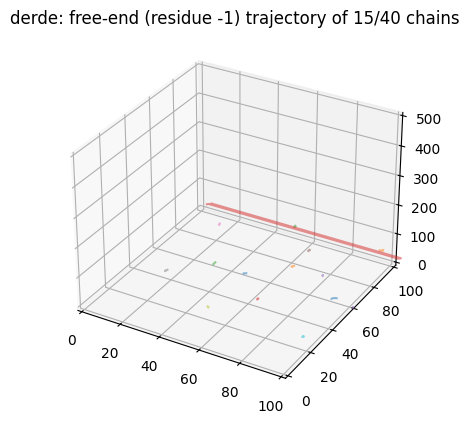

In [26]:
fig = plt.figure()
ax = plt.axes(projection='3d')

max_chains_3d = 15
sample_chain_idx = np.linspace(0, n_chains - 1, min(max_chains_3d, n_chains), dtype=int)

trajectories = []
for c in sample_chain_idx:
    positions = get_pos_of_residue(c, free_idx)
    trajectories.append(positions)

    ax.plot3D(positions[:, 0], positions[:, 1], positions[:, 2], alpha=.5)

ax.axes.set_xlim3d([0, box[0]])
ax.axes.set_ylim3d([0, box[1]])
ax.axes.set_zlim3d([0, box[2]])
ax.set_title(f"{sim_name}: free-end (residue {free_idx}) trajectory of {len(sample_chain_idx)}/{n_chains} chains")

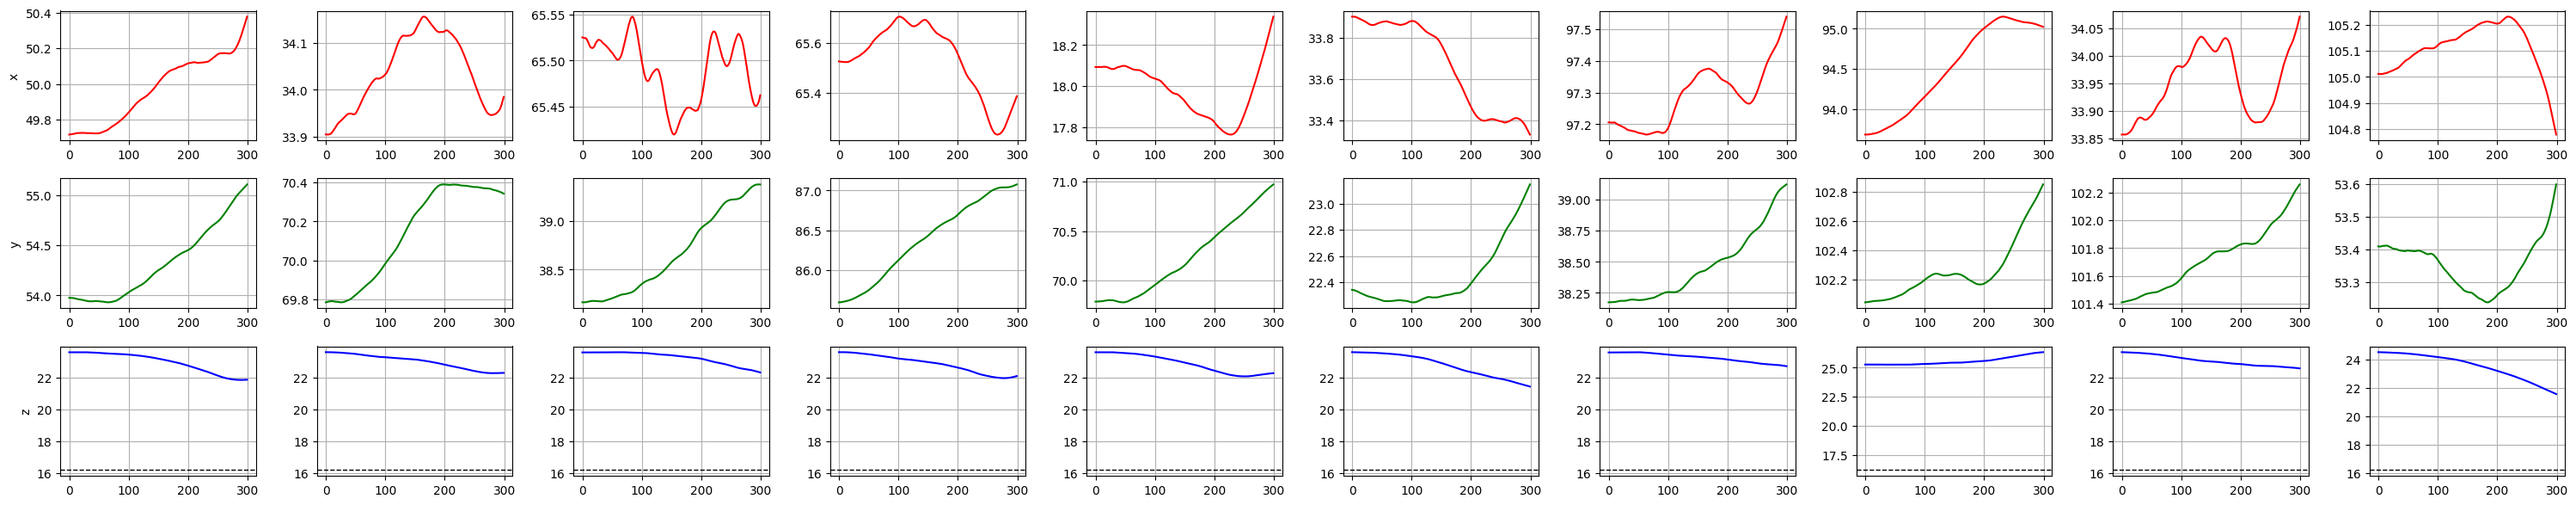

KeyboardInterrupt: 

In [27]:
import matplotlib.pyplot as plt

plt.ion()

max_chains_grid = 10
grid_chain_idx = np.linspace(0, n_chains - 1, min(max_chains_grid, n_chains), dtype=int)
n_cols = len(grid_chain_idx)

anchor_z = min(mean_z_first, mean_z_last)  # reference line: mean z of the anchored end
axis_labels = ["x", "y", "z"]
colors = ["red", "green", "blue"]

fig, axs = plt.subplots(3, n_cols, figsize=(3 * n_cols, 6), squeeze=False)
fig.tight_layout()

for i, c in enumerate(grid_chain_idx):
    axs[0, i].set_title(f"chain {chains[c].segid}")

while True:
    for i, c in enumerate(grid_chain_idx):
        positions = get_pos_of_residue(c, free_idx)

        for j in range(3):
            axs[j, i].clear()  # Clear the previous frame
            axs[j, i].plot(positions[:, j], color=colors[j])
            axs[j, i].grid()
            if i == 0:
                axs[j, i].set_ylabel(axis_labels[j])

        # Redraw the reference line after the z-row's clear() above, or it
        # would be wiped before ever being shown.
        axs[2, i].axhline(anchor_z, color="black", linestyle="--", linewidth=1)

    fig.canvas.draw()
    fig.canvas.flush_events()
    plt.pause(1.5)